<a href="https://colab.research.google.com/github/madhurrathod/nutrition_vs_obesity_trends/blob/main/Food_Environment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This section is done by - Madhur Rathod

Problem Statement - Finding Relation between food intake and obesity

Dataset: Food Consumption, Nutrient Intakes, and Diet Quality

Table 3: Daily nutrient intake and share by food source, 1977–2018

https://www.ers.usda.gov/data-products/food-consumption-nutrient-intakes-and-diet-quality

Reason: This dataset is clean

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd;
import numpy as np;
import matplotlib.pyplot as plt;
import pandas as pd;

In [3]:
excel_file = pd.ExcelFile("/content/drive/MyDrive/Data_Mining_Folder/food_intake/table-3-US-nutrient-intake-and-share-by-food-source.xlsx")

In [4]:
excel_file.sheet_names

['US consumers aged 2 and above',
 'Sex - Males',
 'Sex - Females',
 'Ages 2–19',
 'Ages 20–64',
 'Ages 65 and above',
 'Cohort - Boys age 2–19',
 'Cohort - Girls age 2–19',
 'Cohort - Men age 20 and above',
 'Cohort - Women age 20 and above',
 'Income - low-income households',
 'Income - mid-income households',
 'Income - high-income households',
 'Race - Non-Hispanic White',
 'Race - Non-Hispanic Black',
 'Race - Hispanic',
 'Race - Other racial & ethnic ',
 'Edu. - Less than high school',
 'Edu. - High school degree',
 'Edu. - College attended']

In [5]:
low_income = pd.read_excel("/content/drive/MyDrive/Data_Mining_Folder/food_intake/table-3-US-nutrient-intake-and-share-by-food-source.xlsx", sheet_name = 'Income - low-income households')

In [6]:
mid_income = pd.read_excel("/content/drive/MyDrive/Data_Mining_Folder/food_intake/table-3-US-nutrient-intake-and-share-by-food-source.xlsx", sheet_name = 'Income - mid-income households' )

In [7]:
high_income = pd.read_excel("/content/drive/MyDrive/Data_Mining_Folder/food_intake/table-3-US-nutrient-intake-and-share-by-food-source.xlsx", sheet_name = 'Income - high-income households')

In [8]:
low_income.columns

Index(['Table 3D1—Daily nutrient intake and share by food source for low-income households (below 186 percent of the poverty line), 1977–2018',
       'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5',
       'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10',
       'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13', 'Unnamed: 14',
       'Unnamed: 15', 'Unnamed: 16', 'Unnamed: 17', 'Unnamed: 18',
       'Unnamed: 19', 'Unnamed: 20', 'Unnamed: 21', 'Unnamed: 22',
       'Unnamed: 23', 'Unnamed: 24'],
      dtype='object')

In [9]:
low_income

,"Table 3D1—Daily nutrient intake and share by food source for low-income households (below 186 percent of the poverty line), 1977–2018",Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24
0,NaN,NaN,NaN,1977–1978,NaN,1989–1991,NaN,1994–1998,NaN,2003–2004,...,2009–2010,NaN,2011–2012,NaN,2013–2014,NaN,2015–2016,NaN,2017–2018,NaN
1,Nutrient,Food Source,Measurement,Mean,SE of mean,Mean,SE of mean,Mean,SE of mean,Mean,...,Mean,SE of mean,Mean,SE of mean,Mean,SE of mean,Mean,SE of mean,Mean,SE of mean
2,Energy,Total,Calories,1740.77,11.32,1724.88,22.92,1971.7,33.68,2179.43,...,2050.2,21.97,2126.44,30.65,2043.17,18.94,1992.09,20.26,2032.53,31.63
3,Energy,FAH,Percent of total,83.96,0.55,78.63,0.72,73.06,0.82,71.02,...,73.09,0.57,68.3,1.78,70.22,0.83,70.31,0.96,69.63,1.5
4,Energy,FAFH,Percent of total,16.04,0.55,21.37,0.72,26.94,0.82,28.98,...,26.91,0.57,31.7,1.78,29.78,0.83,29.69,0.96,30.37,1.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
83,Sodium,FAFH: Fast food,Percent of total,4.26,0.23,11.1,0.63,11.13,0.52,17.44,...,15.14,0.48,18.23,1.55,16.71,0.65,15.33,0.76,17.86,1.27
84,Sodium,FAFH: School,Percent of total,3.96,0.15,3.28,0.28,3.58,0.24,2.88,...,3.32,0.38,3.31,0.4,3.07,0.3,2.73,0.33,2.27,0.35
85,Sodium,FAFH: Others,Percent of total,4.88,0.26,3.3,0.32,7.04,0.52,4.42,...,5.56,0.33,7.42,0.61,6.95,0.38,7.3,0.37,6.51,0.43
86,SE of mean = Standard error of the mean. FAH =...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
def pre_process(sheet):
  old_col = sheet.columns[0]
  sheet.rename(columns={old_col: "Nutrient"}, inplace=True)

  sheet.drop(columns=['Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5',
        'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8'], axis = 1, inplace = True)

  sheet.rename(columns ={"Unnamed: 1":"Food Source", "Unnamed: 2": "Measurement"}, inplace = True)

  for i in range(10,25,2):
    sheet.drop(columns={f"Unnamed: {i}"},inplace = True)

  sheet.drop(index = [86,87], inplace = True)

  for col in sheet.columns:
    if "Unnamed" in col:
      # print(col, low_income.loc[0,col])
      sheet.rename(columns = {col: sheet.loc[0,col]}, inplace = True)

  sheet.drop([0,1],axis = 0, inplace = True)

  sheet.reset_index(drop = True, inplace = True)
  sheet.index += 1

  for i in range(1,84):
      if sheet.loc[i,"Food Source"] != "Total":
        sheet.drop(i,axis = 0, inplace = True)

  sheet.drop(84, inplace = True)

  sheet.reset_index(drop = True, inplace = True)
  sheet.index += 1
  return sheet

In [11]:
low_income = pre_process(low_income)

In [12]:
mid_income = pre_process(mid_income)

In [13]:
high_income = pre_process(high_income)

In [14]:
low_income

,Nutrient,Food Source,Measurement,2003–2004,2005–2006,2007–2008,2009–2010,2011–2012,2013–2014,2015–2016,2017–2018
1,Energy,Total,Calories,2179.43,2089.87,2007.41,2050.2,2126.44,2043.17,1992.09,2032.53
2,Calcium,Total,Milligrams,895.84,922.01,906.4,984.45,1007.34,949.12,919.4,934.46
3,"Fiber, dietary",Total,Grams,14.21,14.37,14.29,15.29,16.22,15.44,15.62,15.46
4,Iron,Total,Milligrams,15.44,15.11,14.03,14.3,15.18,14.21,13.75,13.82
5,Protein,Total,Grams,78.25,78.1,74.85,76.24,78.3,77.33,75.2,74
6,Carbohydrate,Total,Grams,278,264.42,253.36,263.14,270.81,253.47,243.63,248.43
7,Cholesterol,Total,Milligrams,271.37,272.48,271.6,259.4,267.3,271.62,276.89,271.6
8,Total Fat,Total,Grams,81.12,77.59,74.81,74.25,78.44,77.72,77.71,80.35
9,Saturated fatty acids,Total,Grams,27.49,26.33,25.33,24.85,25.92,25.61,25.97,26.4
10,"Fatty acids, monounsaturated",Total,Grams,30.39,28.53,27.42,26.63,27.6,26.71,26.92,27.04


In [15]:
mid_income

,Nutrient,Food Source,Measurement,2003–2004,2005–2006,2007–2008,2009–2010,2011–2012,2013–2014,2015–2016,2017–2018
1,Energy,Total,Calories,2148.67,2107.25,2001.61,2043.31,2039.08,2116.77,2029.01,2160.13
2,Calcium,Total,Milligrams,904.84,936.57,924.26,1011.41,927.36,991.01,977.16,981.6
3,"Fiber, dietary",Total,Grams,14.45,14.13,14.63,15.92,15.96,15.7,16.09,16.26
4,Iron,Total,Milligrams,15.29,15.36,14.02,15.29,14.28,14.84,14.06,14.53
5,Protein,Total,Grams,77.74,78.09,75.99,79,74.76,80.83,78.21,79.49
6,Carbohydrate,Total,Grams,271.73,259.41,246.71,256.32,254.48,257.95,241.97,257.83
7,Cholesterol,Total,Milligrams,257.8,263.26,263.76,265.39,257.24,284.32,293.28,297.09
8,Total Fat,Total,Grams,80.73,81.06,76.29,75.61,76.16,80.74,80.85,87.76
9,Saturated fatty acids,Total,Grams,26.85,28.17,25.92,25.15,25.16,26.75,27.48,29.2
10,"Fatty acids, monounsaturated",Total,Grams,30.25,29.97,27.76,27.26,27,27.53,28.05,29.81


In [16]:
high_income

,Nutrient,Food Source,Measurement,2003–2004,2005–2006,2007–2008,2009–2010,2011–2012,2013–2014,2015–2016,2017–2018
1,Energy,Total,Calories,2228.39,2223.45,2155.68,2122.99,2192.11,2101.5,2110.72,2126.73
2,Calcium,Total,Milligrams,942.99,1015.35,992.19,1077.57,1051.22,1002.95,983.19,995.09
3,"Fiber, dietary",Total,Grams,15.58,16.03,16.18,17.21,18.73,17.39,17.52,16.91
4,Iron,Total,Milligrams,16.01,16.66,15.72,15.4,16.11,14.37,14.13,13.91
5,Protein,Total,Grams,83.53,85.74,82.06,82.87,83.69,83.03,82.5,81.93
6,Carbohydrate,Total,Grams,271.58,266.76,262.61,256.34,264.96,246.46,243.55,241.61
7,Cholesterol,Total,Milligrams,280.97,287.96,285.09,259.87,271.51,278.25,282.24,298.94
8,Total Fat,Total,Grams,84.86,85.17,82.46,79.79,83.2,81.98,85.29,88.5
9,Saturated fatty acids,Total,Grams,28.15,28.69,27.47,26.29,26.89,26.72,27.92,29.11
10,"Fatty acids, monounsaturated",Total,Grams,31.85,31.28,30.5,28.47,29.84,28.42,29.98,30.23


In [17]:
low_income_energy = low_income[low_income["Nutrient"].str.strip() == "Energy"].iloc[0, 3:]
mid_income_energy = mid_income[low_income["Nutrient"].str.strip() == "Energy"].iloc[0, 3:]
high_income_energy = high_income[low_income["Nutrient"].str.strip() == "Energy"].iloc[0, 3:]

In [18]:
low_income_energy

,1
2003–2004,2179.43
2005–2006,2089.87
2007–2008,2007.41
2009–2010,2050.2
2011–2012,2126.44
2013–2014,2043.17
2015–2016,1992.09
2017–2018,2032.53


In [19]:
df_energy = pd.DataFrame({
    "Year": low_income_energy.index,
    "Low": low_income_energy.values,
    "Mid": mid_income_energy.values,
    "High": high_income_energy.values
})
df_energy

,Year,Low,Mid,High
0,2003–2004,2179.43,2148.67,2228.39
1,2005–2006,2089.87,2107.25,2223.45
2,2007–2008,2007.41,2001.61,2155.68
3,2009–2010,2050.2,2043.31,2122.99
4,2011–2012,2126.44,2039.08,2192.11
5,2013–2014,2043.17,2116.77,2101.5
6,2015–2016,1992.09,2029.01,2110.72
7,2017–2018,2032.53,2160.13,2126.73


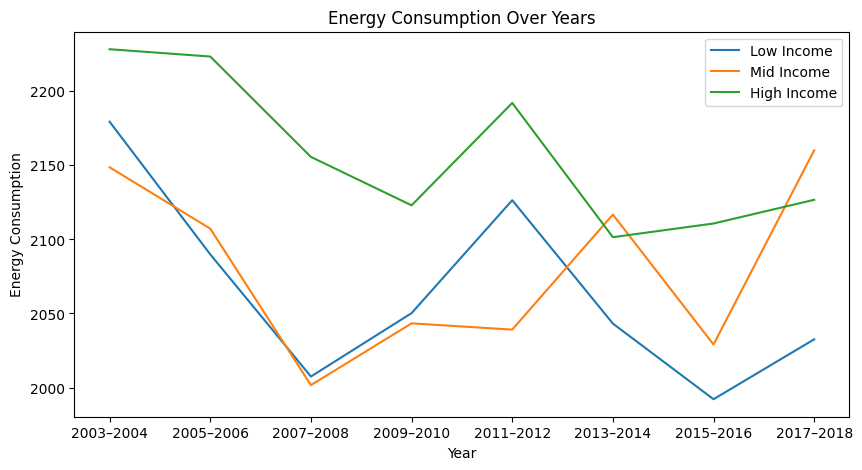

In [20]:
plt.figure(figsize=(10,5))

plt.plot(df_energy["Year"], df_energy["Low"])
plt.plot(df_energy["Year"], df_energy["Mid"])
plt.plot(df_energy["Year"], df_energy["High"])

plt.xlabel("Year")
plt.ylabel("Energy Consumption")
plt.title("Energy Consumption Over Years")
plt.legend(["Low Income", "Mid Income", "High Income"])

plt.show()


In [21]:
measurement = low_income[low_income["Nutrient"]=="Calcium "]["Measurement"].iloc[0]
measurement

'Milligrams'

In [22]:
def nutrient_plotter(low_income, mid_income, high_income, nutrient_name):
  low_income_nutrient = low_income[low_income["Nutrient"].str.strip() == nutrient_name].iloc[0, 3:]
  mid_income_nutrient = mid_income[low_income["Nutrient"].str.strip() == nutrient_name].iloc[0, 3:]
  high_income_nutrient = high_income[low_income["Nutrient"].str.strip() == nutrient_name].iloc[0, 3:]

  df = pd.DataFrame({
    "Year": low_income_nutrient.index,
    "Low": low_income_nutrient.values,
    "Mid": mid_income_nutrient.values,
    "High": high_income_nutrient.values
  })

  measurement = low_income[low_income["Nutrient"].str.strip() == nutrient_name]["Measurement"].iloc[0]

  plt.figure(figsize=(10,5))

  plt.plot(df["Year"], df["Low"])
  plt.plot(df["Year"], df["Mid"])
  plt.plot(df["Year"], df["High"])

  plt.xlabel("Year")
  plt.ylabel(f"{nutrient_name} Consumption ({measurement}) ")
  plt.title(f"{nutrient_name} Consumption Over Years")
  plt.legend(["Low Income", "Mid Income", "High Income"])

  plt.show()

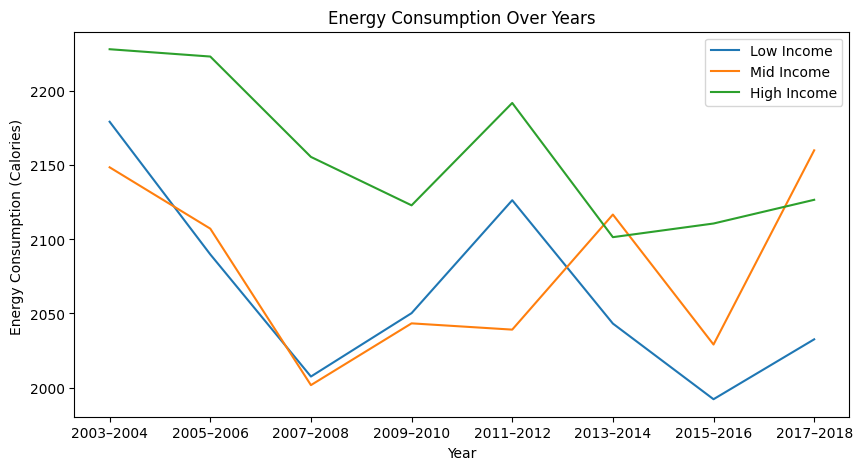

In [23]:
nutrient_plotter(low_income, mid_income, high_income, "Energy")

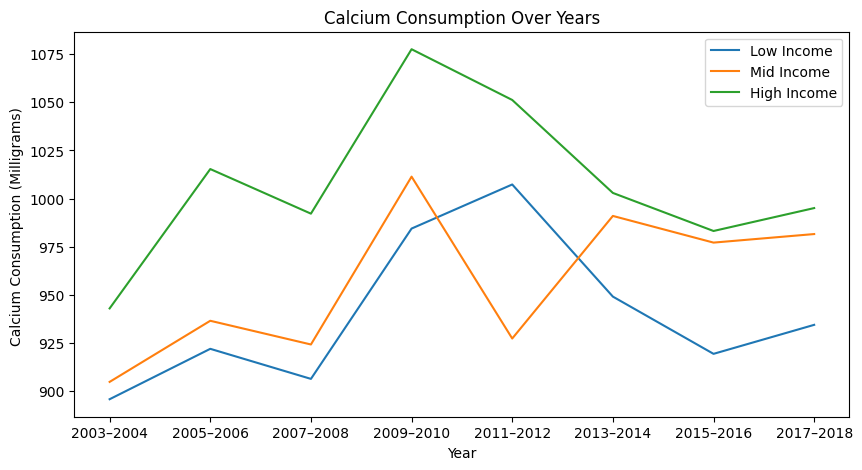

In [24]:
nutrient_plotter(low_income, mid_income, high_income, "Calcium")

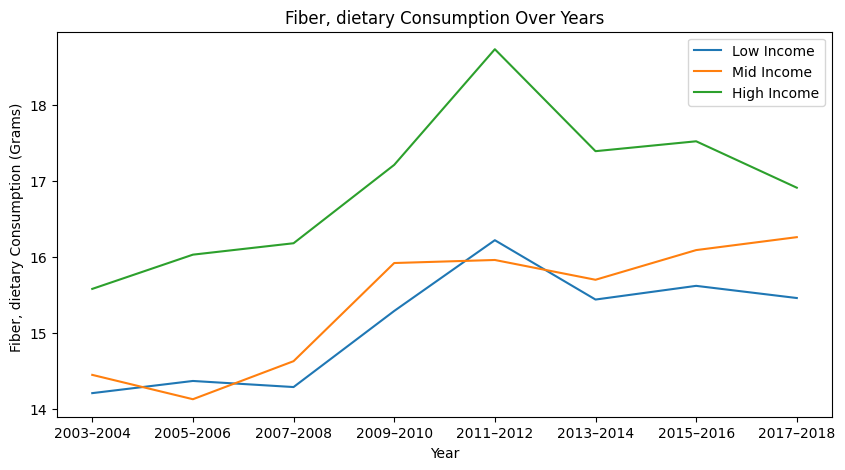

In [25]:
nutrient_plotter(low_income, mid_income, high_income, "Fiber, dietary")

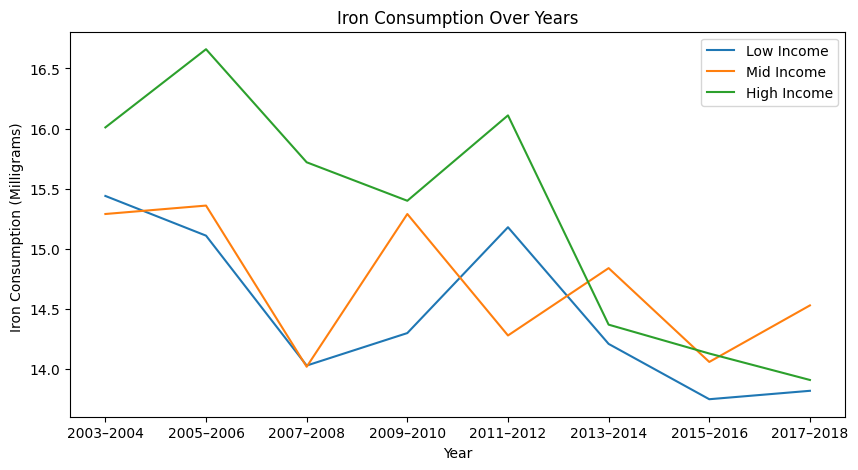

In [26]:
nutrient_plotter(low_income, mid_income, high_income, "Iron")

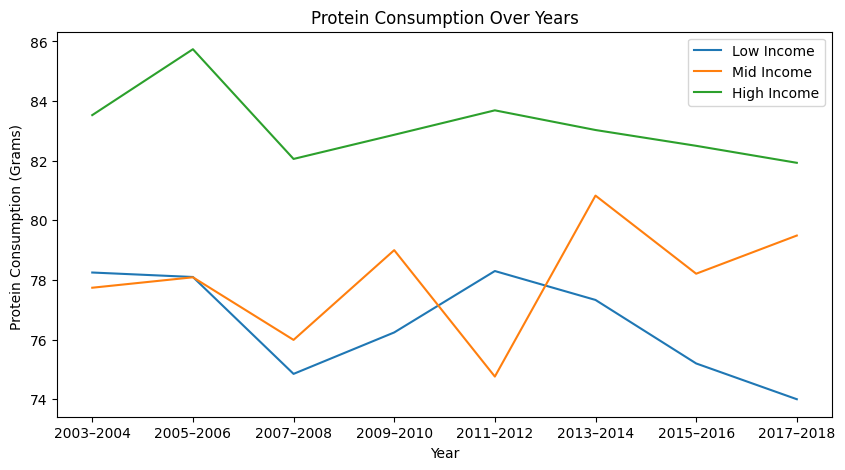

In [27]:
nutrient_plotter(low_income, mid_income, high_income, "Protein")

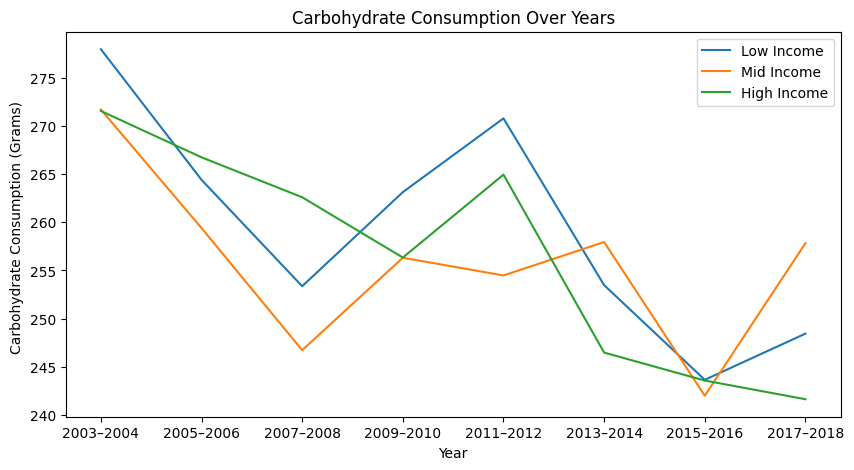

In [28]:
nutrient_plotter(low_income, mid_income, high_income, "Carbohydrate")

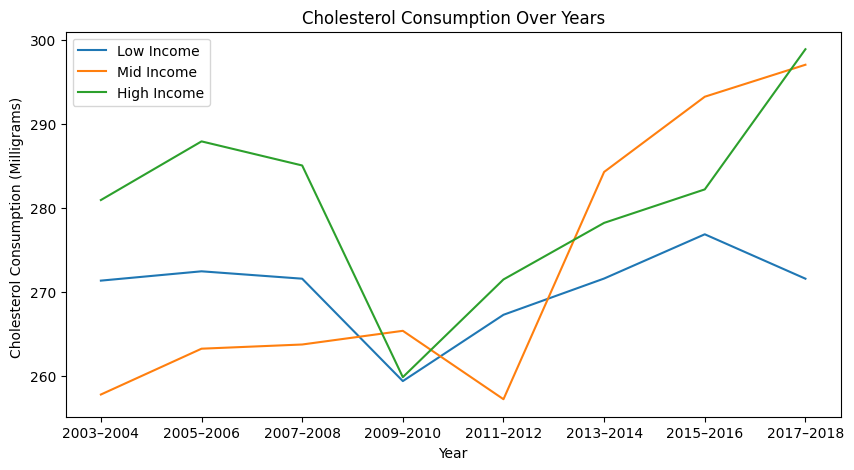

In [29]:
nutrient_plotter(low_income, mid_income, high_income, "Cholesterol")

High cholestrol consumption in low and mid income groups shows higher chances of getting into diseases due to low quality diet.

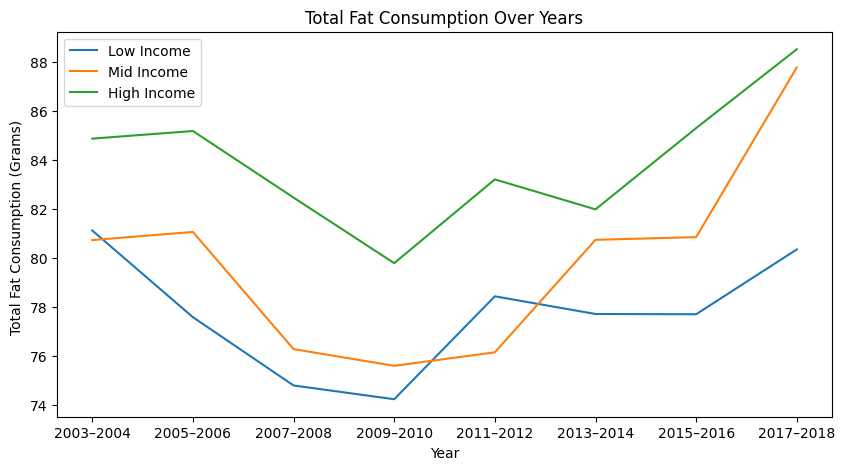

In [30]:
nutrient_plotter(low_income, mid_income, high_income, "Total Fat")

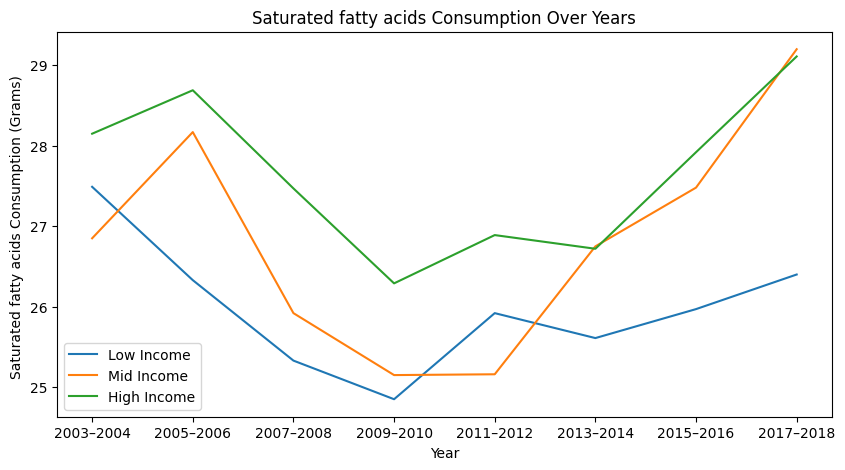

In [31]:
nutrient_plotter(low_income, mid_income, high_income, "Saturated fatty acids")

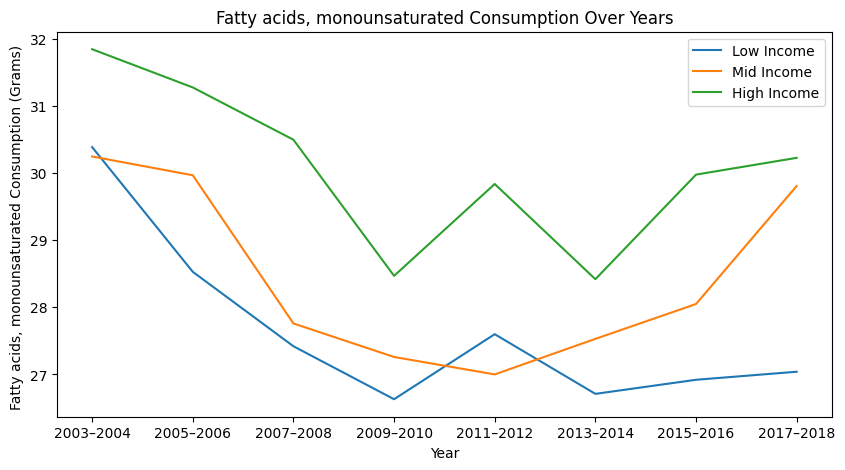

In [32]:
nutrient_plotter(low_income, mid_income, high_income, "Fatty acids, monounsaturated")

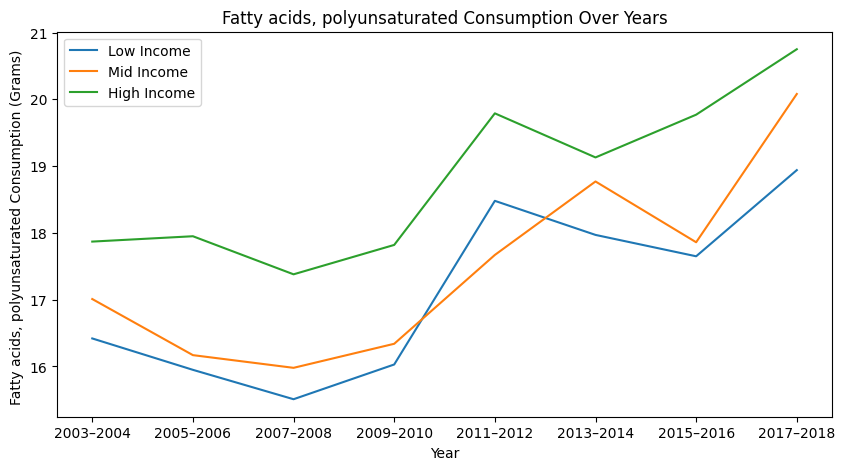

In [33]:
nutrient_plotter(low_income, mid_income, high_income, "Fatty acids, polyunsaturated")

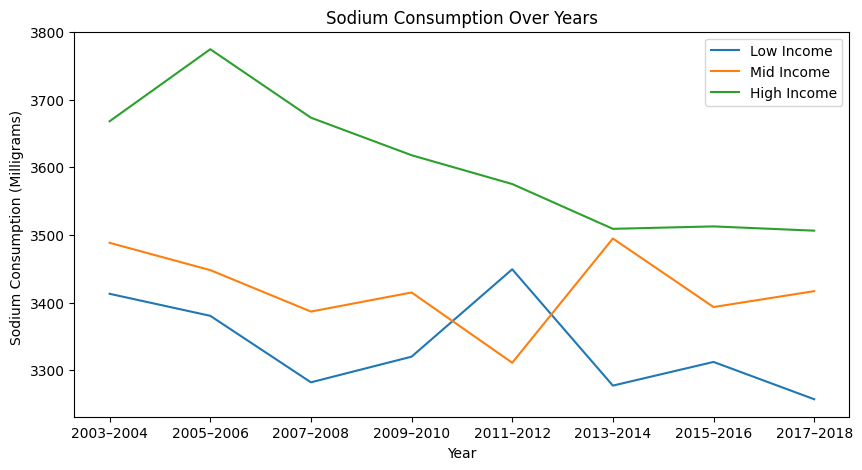

In [34]:
nutrient_plotter(low_income, mid_income, high_income, "Sodium")

In [35]:
!pip install mlxtend

In [39]:

import pandas as pd
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

# --- 1. Load and Clean Data ---
file_path = excel_file

def process_sheet(sheet_name, income_group):
    """Extracts and flattens data from the specific Excel sheet structure."""
    try:
        xl = pd.ExcelFile(file_path)
        df = xl.parse(sheet_name, header=None)

        # Extract years from Row 1 (indices 3, 5, 7...)
        years = [df.iloc[1, c] for c in range(3, df.shape[1], 2)]

        # Extract data from Row 3 onwards
        data = df.iloc[3:].copy()

        records = []
        for _, row in data.iterrows():
            nutrient = row.iloc[0]
            food_source = row.iloc[1]
            measurement = row.iloc[2]

            # Iterate over year pairs (Mean, SE)
            for i, year in enumerate(years):
                col_mean = 3 + (i * 2)
                if col_mean >= len(row): break

                mean_val = row.iloc[col_mean]

                # Filter out invalid rows
                if pd.notna(mean_val) and pd.notna(food_source):
                    records.append({
                        'Income_Group': income_group,
                        'Nutrient': nutrient,
                        'Food_Source': food_source,
                        'Measurement': measurement,
                        'Mean': mean_val
                    })
        return pd.DataFrame(records)
    except Exception as e:
        print(f"Error processing {sheet_name}: {e}")
        return pd.DataFrame()

# Combine all groups
print("Processing datasets...")
df_low = process_sheet('Income - low-income households', 'Low')
df_mid = process_sheet('Income - mid-income households', 'Mid')
df_high = process_sheet('Income - high-income households', 'High')
df = pd.concat([df_low, df_mid, df_high], ignore_index=True)

if not df.empty:
    # --- 2. Prepare for Association Mining ---
    # Discretize 'Mean' into Low/Med/High bins per Nutrient/Measurement context
    # This is crucial to compare "Energy" (2000+) with "Calcium" (1000+) fairly
    df['Intake_Level'] = df.groupby(['Nutrient', 'Measurement'])['Mean'].transform(
        lambda x: pd.qcut(x, 3, labels=['Low_Intake', 'Med_Intake', 'High_Intake'], duplicates='drop')
    )

    # Create Transactions: List of attributes for each record
    transactions = []
    for _, row in df.iterrows():
        transactions.append([
            f"Income={row['Income_Group']}",
            f"Source={row['Food_Source']}",
            f"Intake={row['Intake_Level']}"
        ])

    # --- 3. Run Apriori Algorithm ---
    print("Running Apriori Algorithm...")
    te = TransactionEncoder()
    te_ary = te.fit(transactions).transform(transactions)
    df_trans = pd.DataFrame(te_ary, columns=te.columns_)

    # Min Support 0.5% (0.005) to capture specific patterns in the diverse dataset
    frequent_itemsets = apriori(df_trans, min_support=0.005, use_colnames=True)

    # Generate Rules with high confidence
    rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.5)

    # --- 4. Filter for Income Insights ---
    # We are interested in rules where 'Income' is the Consequent (Result)
    income_rules = rules[rules['consequents'].apply(lambda x: any('Income=' in str(i) for i in x))]
    income_rules = income_rules.sort_values('lift', ascending=False)

    # Display Results
    print("\n--- Top Insights (Association Rules) ---")
    cols = ['antecedents', 'consequents', 'support', 'confidence', 'lift']
    print(income_rules[cols].head().to_string())

    # Interpretation
    print("\n--- Interpretation ---")
    print("Lift > 1.0 indicates a positive correlation.")
    print("Example: If {Source=Restaurant, Intake=Low} -> {Income=Low} has Lift 1.9,")
    print("it means people with low restaurant intake are 1.9x more likely to be low income.")
else:
    print("No data found. Please check the file path and sheet names.")

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Processing datasets...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Running Apriori Algorithm...

--- Top Insights (Association Rules) ---
                                     antecedents    consequents   support  confidence      lift
18  (Intake=Low_Intake, Source=FAFH: Restaurant)   (Income=Low)  0.034632    0.657534  1.972603
8             (Source=Total, Intake=High_Intake)  (Income=High)  0.029942    0.628788  1.886364

--- Interpretation ---
Lift > 1.0 indicates a positive correlation.
Example: If {Source=Restaurant, Intake=Low} -> {Income=Low} has Lift 1.9,
it means people with low restaurant intake are 1.9x more likely to be low income.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag